# Simulations V2

What's changed:
- new flux computation for stars, assuming a spectral type (fixed)
- 

## Import

In [1]:
import numpy as np
import pandas as pd
import bincatsim as bs
import astropy.units as u
from matplotlib import pyplot as plt
from scipy.signal import argrelextrema
from importlib import reload
from tqdm import tqdm

import grasp as gp
stats = gp.stats

home = '/home/pietrof'

lf = gp.plots.label_font
lf['size'] = 18

tf = gp.plots.title_font
tf['size'] = 22

def plot_groups(
    data,
    x,
    y,
    hue:str = None,
    hue_label:str = None,
    xlabel: str = None,
    ylabel: str = None,
    title : str =None,
    **kwargs
):
    fs = kwargs.pop('figsize', (10,8))
    lon = kwargs.pop('legend', True)
    yscale = kwargs.pop('yscale', None)
    if hue is not None:
        if isinstance(hue, str) and hue in data.columns:
            data = {dm: data[data[hue] == dm] for dm in data[hue].unique()} if hue else data
        else:
            try:
                data = {0: data[hue]}
                lon = False
            except Exception as e:
                print(f"Error processing hue: {e}")
                data = {0: data}
                lon = False
    else:
        data = {0: data}
        lon = False

    plt.figure(figsize=fs)
    for dm, group in data.items():
        plt.plot(group[x], group[y], '-o', label=f'{hue_label or hue} = {float(dm):.2}', alpha=0.7, **kwargs)
    plt.xlabel(xlabel or x, fontdict=gp.plots.label_font)
    plt.ylabel(ylabel or y, fontdict=gp.plots.label_font)
    plt.title(title or f"{y.upper()} vs {x.upper()}", fontdict=gp.plots.title_font)
    plt.grid(linestyle='--', alpha=0.5)
    if lon:
        plt.legend(title='HUE', loc='best', fontsize='large')
    if yscale:
        plt.yscale(yscale)
    plt.tick_params(axis='both', labelsize=14)
    plt.show()
    

sd = pd.read_csv(bs.paths.SIM_RECORD_FILE)


[XuPy] Device 0 available - GPU : `NVIDIA GeForce RTX 5080 Laptop GPU`
       Memory = 16220.22 MB | Compute Capability = 12.0
       Using CuPy 13.6.0 for acceleration.


/home/pietrof/miniforge3/envs/bincat/lib/python3.13/site-packages/cupyx/jit/_interface.py:173: FutureWarning: cupyx.jit.rawkernel is experimental. The interface can change in the future.
  cupy._util.experimental('cupyx.jit.rawkernel')


In [3]:
cube = bs.load_psf(tn_or_fp='20260608_135844')

In [27]:
cube.calibration.psf_2d

array([], shape=(36, 0), dtype='>f4')

In [31]:
ccd = bs.CCD(bs.paths.PSF_FILE)
sim = bs.GaiaSimulator(
    ccd = ccd,
    central_star=bs.Star(magnitude=14),
    companion_star=bs.Star(magnitude=14),
    distance=220,
    angle=90
)

print(f"{ccd.ccd_pxscale_factor = }")

psf = np.random.normal(2, 0.5, (2124,1062))

for i, condition in enumerate(ccd._wc_conditions):
    if eval(condition.format(G=14)):
        wc_px = ccd.WC[i]["area_px"]
        window = f"wc{i}"
        break

print(f"{window = } : {ccd.WC[i]['area_px']}")

rbx = psf.shape[1] // wc_px[0]
rby = psf.shape[0] // wc_px[1]
rbratio = (rby, rbx) if ccd.ccd_pxscale_factor > 1 else (rbx, rby)

print(f"{rbx = }, {rby = }, {rbratio = }")

import poppy
psf_2d = poppy.utils.rebin_array(psf, rbratio)

print(f"{psf_2d.shape = }")

psf_x, psf_y = bs.computeXandYpsf(psf=psf_2d)

print(f"{psf_x.shape = }, {psf_y.shape = }")

ccd.ccd_pxscale_factor = 3.0
window = 'wc1' : (18, 1)
rbx = 59, rby = 2124, rbratio = (2124, 59)
psf_2d.shape = (1, 18)
psf_x.shape = (18,), psf_y.shape = (1,)


In [38]:
list2d = []
listal = []
for img in sim.transit():
    cv = bs.convolve_fft(img, ccd.psf, boundary='wrap', normalize_kernel=True)
    psf_2d, _, _ = ccd.sample_psf(cv, G=14)
    list2d.append(psf_2d)

    psf_x, psf_y = bs.computeXandYpsf(psf=psf_2d)

    listal.append(psf_x)

In [45]:
np.sum(list2d[0], axis=1)

array([109901.89], dtype=float32)

## Visualizations

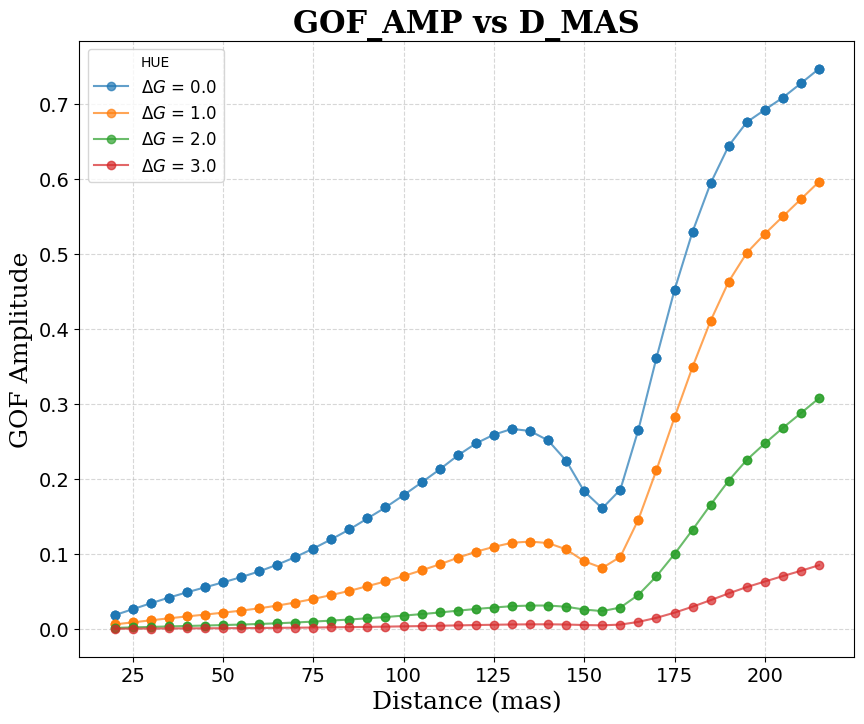

In [2]:
plot_groups(sd, x='D_mas', y='gof_amp', hue='delta_m', hue_label=r"$\Delta G$", xlabel='Distance (mas)', ylabel='GOF Amplitude')

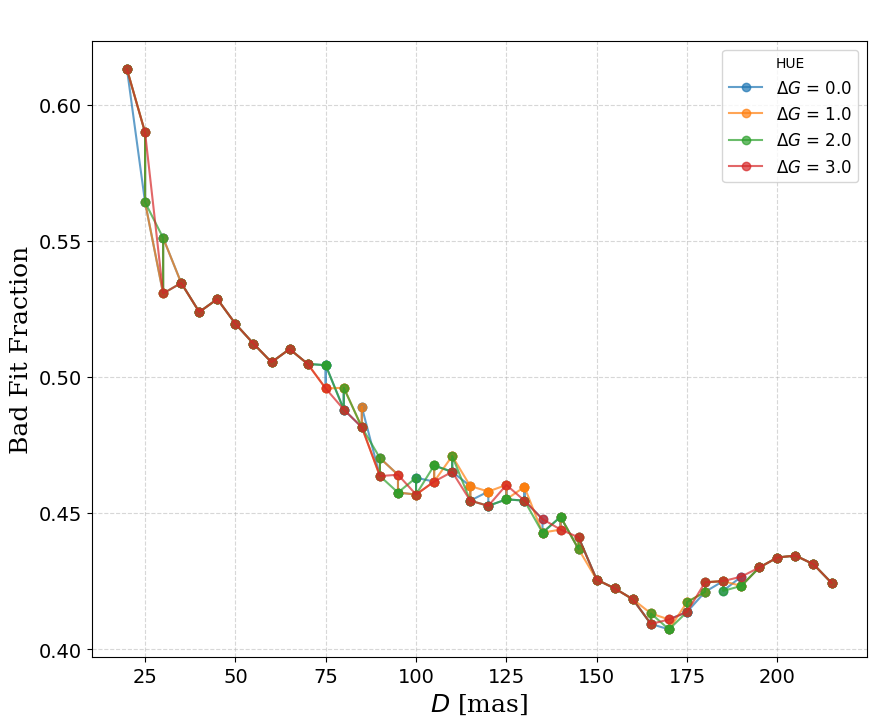

In [3]:
plot_groups(
    sd,
    x='D_mas',
    y='frac_badfit', 
    hue='delta_m',
    hue_label=r"$\Delta G$",
    xlabel=r"$D$ [mas]", 
    ylabel=r"Bad Fit Fraction",
    title=' ', 
    figsize=(10,8),
    legend=True,
    #yscale='log'
)

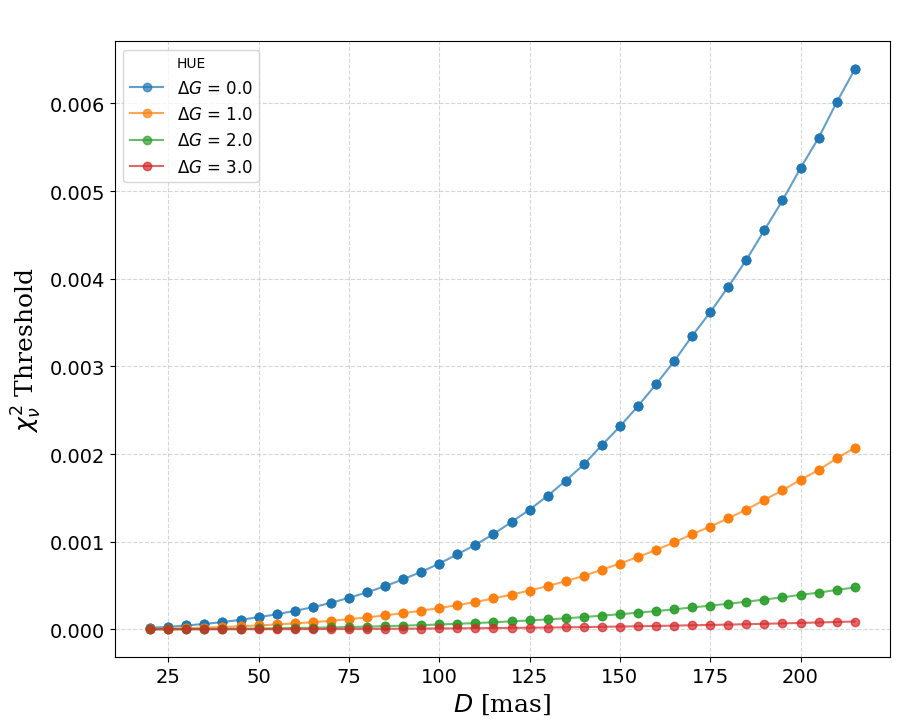

In [4]:
plot_groups(
    sd,
    x='D_mas',
    y='chi2_threshold', 
    hue='delta_m',
    hue_label=r"$\Delta G$",
    xlabel=r"$D$ [mas]", 
    ylabel=r"$\chi^2_\nu$ Threshold",
    title=' ', 
    figsize=(10,8),
    legend=True,
    #yscale='log'
)

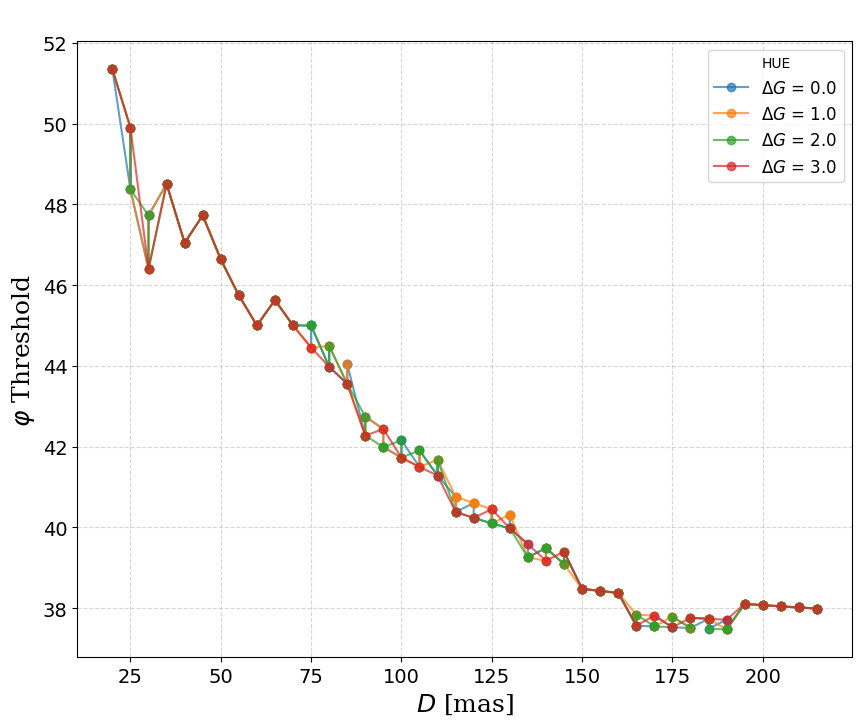

In [5]:
plot_groups(
    sd,
    x='D_mas',
    y='phi_threshold', 
    hue='delta_m',
    hue_label=r"$\Delta G$",
    xlabel=r"$D$ [mas]", 
    ylabel=r"$\varphi$ Threshold",
    title=' ', 
    figsize=(10,8),
    legend=True,
    #yscale='log'
)

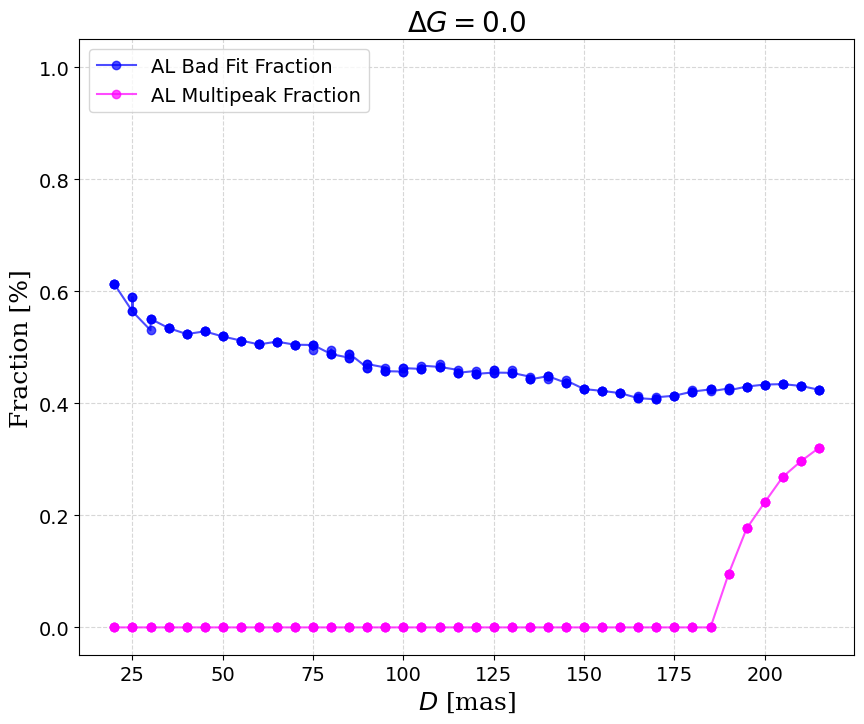

In [6]:
data = sd[sd['delta_m'] == 0.0]

x = data['D_mas']
y0 = data['frac_badfit']
y1 = data['al_multipeak']

fig = plt.figure(figsize=(10,8))
plt.plot(x, y0, '-o', label='AL Bad Fit Fraction', color='blue', alpha=0.7)
plt.plot(x, y1, '-o', label='AL Multipeak Fraction', color='magenta', alpha=0.7)
plt.xlabel(r"$D$ [mas]", fontdict=gp.plots.label_font)
plt.ylabel(r"Fraction [%]", fontdict=gp.plots.label_font)
plt.title(r"$\Delta G = 0.0$", fontdict={'size': 20})
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.ylim(-0.05, 1.05)
plt.grid(linestyle='--', alpha=0.5)
plt.legend(loc='upper left', fontsize=14)

fig.savefig(f"{home}/Desktop/badfit_multipeak.png", dpi=450)